<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
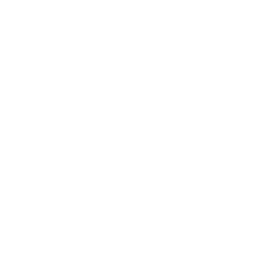
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Prévision de la demande de médicaments sur ordonnance</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutique / Planification de la chaîne d'approvisionnement &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé analytique

Un distributeur régional doit dimensionner ses engagements de production et de stock pour le **CARDIOSTAT 40MG**, un traitement cardiovasculaire d'entretien à demande de renouvellement régulière. Ce notebook construit une prévision de Box-Jenkins du volume mensuel d'exécutions d'ordonnances à partir de **100 mois (un peu plus de huit ans) d'historique** et projette la demande sur douze mois pour la planification de la chaîne d'approvisionnement.

Le flux de travail suit les trois étapes de PROC ARIMA. **IDENTIFY** examine l'autocorrélation (ACF) et l'autocorrélation partielle (PACF) de la série différenciée au premier ordre pour choisir un ordre de modèle. **ESTIMATE** ajuste un ARIMA(1,1,1) par maximum de vraisemblance et capture le tableau des paramètres via ODS OUTPUT à des fins de documentation. **FORECAST** génère une trajectoire à 12 mois avec des intervalles de prédiction à 95%.

L'ARIMA(1,1,1) ajusté produit une **prévision centrale essentiellement plate d'environ 105,400 exécutions par mois**, avec un intervalle à 95% qui s'élargit jusqu'à environ **[71,800; 138,900]** au douzième mois. Ni le terme AR ni le terme MA n'est statistiquement significatif sur cet échantillon, de sorte que le modèle se comporte presque comme une marche aléatoire avec dérive — une base défendable et prudente pour le pré-positionnement des stocks. Chaque chiffre cité ci-dessous est tiré directement de la sortie exécutée.

## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.DRUG_DEMAND | Volumes mensuels synthétiques d'exécutions d'ordonnances pour un NDC (à partir de janvier 1984) | 100 |
| WORK.FORECASTS | Jeu de données PROC ARIMA OUT= : valeurs ajustées + prévision et intervalles sur 12 mois | 112 |

La série de demande est générée synthétiquement avec une tendance de croissance linéaire, un cycle saisonnier annuel et un bruit autocorrélé, puis prévue avec PROC ARIMA.

---

In [1]:
/* --------------------------------------------------------
   Génère une demande mensuelle synthétique d'ordonnances :
   100 mois (~8 ans) de volume d'exécutions, à partir de janvier 1984.
   Structure = tendance linéaire + saisonnalité annuelle + bruit AR.
   -------------------------------------------------------- */
DONNÉES work.drug_demand;
    APPELER streaminit(42);
    ndc_code  = '12345-6789-01';
    drug_name = 'CARDIOSTAT 40MG';
    base_demand = 85000;
    trend = 120;
    prev_error = 0;
    FAIRE month_seq = 1 JUSQU_À 100;
        demand_date = intnx('month', '01JAN1984'd, month_seq - 1);
        year      = year(demand_date);
        month_num = month(demand_date);
        /* motif saisonnier annuel + semestriel */
        seasonal = 4000 * sin(2 * constant('PI') * month_num / 12)
                 + 2000 * cos(2 * constant('PI') * month_num / 6);
        random_shock = round(rand('normal', 0, 3500));
        /* report autorégressif du choc précédent */
        ar_component = 0.6 * prev_error;
        fill_volume = round(base_demand + trend * month_seq + seasonal
                      + ar_component + random_shock);
        SI fill_volume < 10000 ALORS fill_volume = 10000;
        prev_error = random_shock;
        revenue = round(fill_volume * 4.85, 0.01);
        SORTIE;
    FIN;
    SUPPRIMER base_demand trend seasonal random_shock ar_component
         prev_error month_num;
    ÉTIQUETTE fill_volume = "Volume d'exécutions"
          revenue     = "Chiffre d'affaires"
          year        = "Année"
          demand_date = "Mois";
    format demand_date monyy7. revenue dollar12.2;
EXÉCUTER;


NOTE: DATA work.drug_demand


NOTE: Wrote work.drug_demand (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

In [2]:
/* --------------------------------------------------------
   Synthèse annuelle de la demande : moyenne / dispersion des
   exécutions mensuelles et du chiffre d'affaires par année civile.
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.drug_demand n mean std MIN MAX maxdec=0;
    CLASSE year;
    VAR fill_volume revenue;
    TITRE "Synthèse annuelle de la demande du médicament : CARDIOSTAT 40MG";
EXÉCUTER;

                            Synthèse annuelle de la demande du médicament : CARDIOSTAT 40MG                             

                                                  The MEANS Procedure

                                  Analysis Variable : fill_volume Volume d'exécutions

        Année             N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1984                 12          83534           5857          74202          90189
        1985                 12          86676           5080          78290          92470
        1986                 12          87213           4266          79050          91718
        1987                 12          91119           5476          78822          97289
        1988                 12          94218           5885          84353         102556
        1989                 12          94877           4895          86493


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                            Synthèse annuelle de la demande du médicament : CARDIOSTAT 40MG                             




NOTE: PROC SGPLOT data=work.drug_demand

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


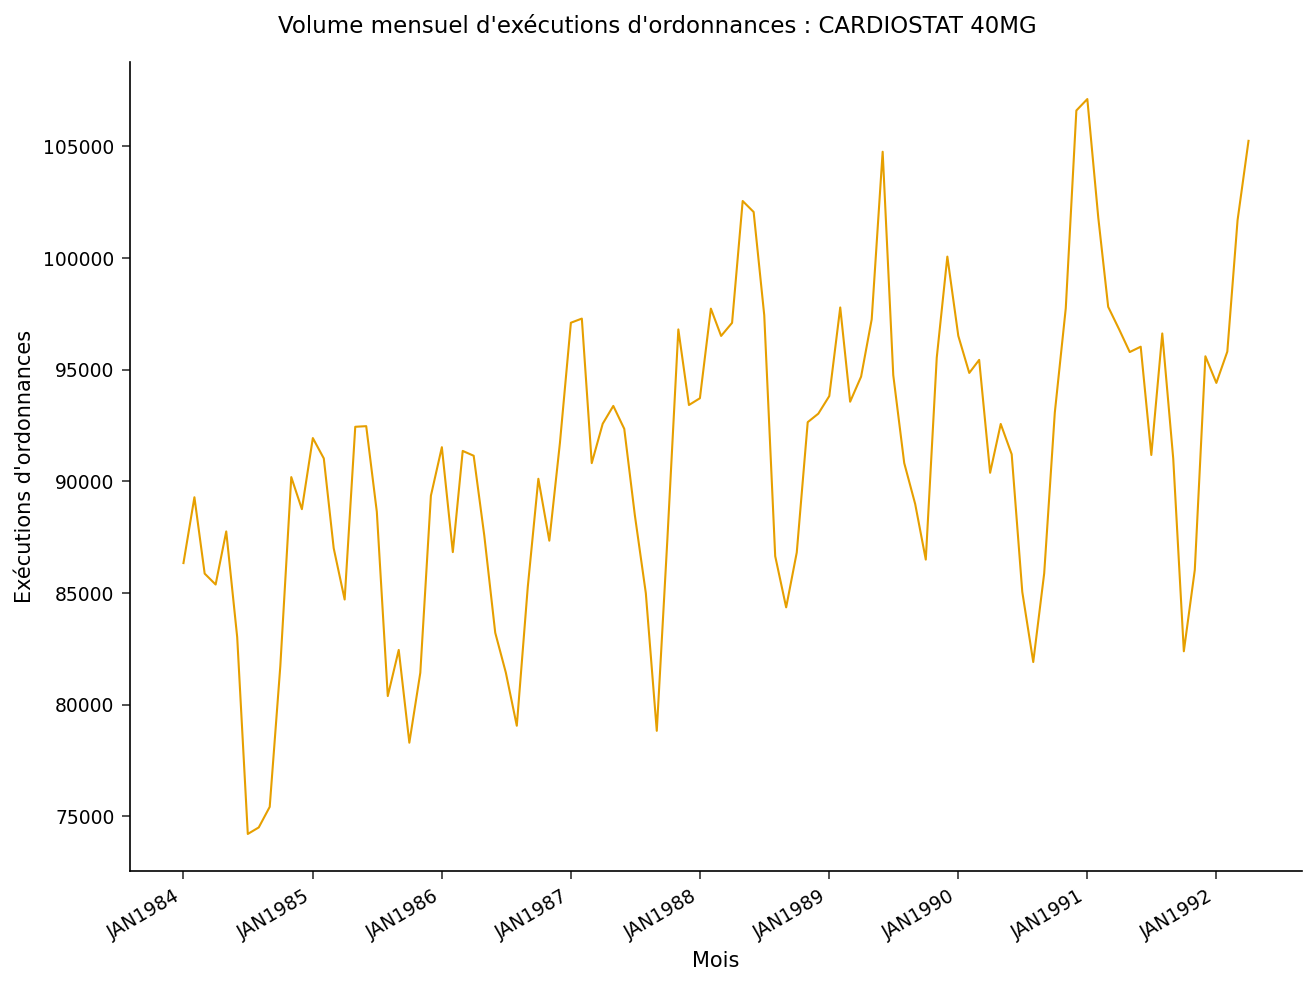

In [3]:
/* --------------------------------------------------------
   Graphique chronologique des volumes mensuels d'exécutions
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.drug_demand;
    SERIES x=demand_date y=fill_volume / LINEATTRS=(thickness=1);
    XAXIS ÉTIQUETTE="Mois";
    YAXIS ÉTIQUETTE="Exécutions d'ordonnances";
    TITRE "Volume mensuel d'exécutions d'ordonnances : CARDIOSTAT 40MG";
EXÉCUTER;

                            Synthèse annuelle de la demande du médicament : CARDIOSTAT 40MG                             

The ARIMA Procedure

Name of Variable = Volume d'exécutions

Number of Observations    100

Descriptive Statistics

  Mean             90982.5600
  Std Dev           6905.4488
  Minimum          74202.0000
  Maximum         107123.0000

Autocorrelations

  Lag    Correlation    Std Error
  ---    -----------    ---------
  Lag   1     0.744824     0.100000
  Lag   2     0.433078     0.100000
  Lag   3     0.247230     0.100000
  Lag   4     0.105029     0.100000
  Lag   5     0.006433     0.100000
  Lag   6     0.047404     0.100000
  Lag   7     0.061895     0.100000
  Lag   8     0.037422     0.100000
  Lag   9     0.070910     0.100000
  Lag  10     0.181341     0.100000
  Lag  11     0.321225     0.100000
  Lag  12     0.442194     0.100000
  Lag  13     0.463728     0.100000
  Lag  14     0.346773     0.100000
  Lag  15     0.235578     0.100000
  Lag  16     0


NOTE: ODS OUTPUT: FITSTATISTICS -> arima_fit
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> arima_params
NOTE: PROC ARIMA data=work.drug_demand

NOTE: Using Python statsmodels version 0.14.6
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.
NOTE: ODS OUTPUT: All output destinations closed.


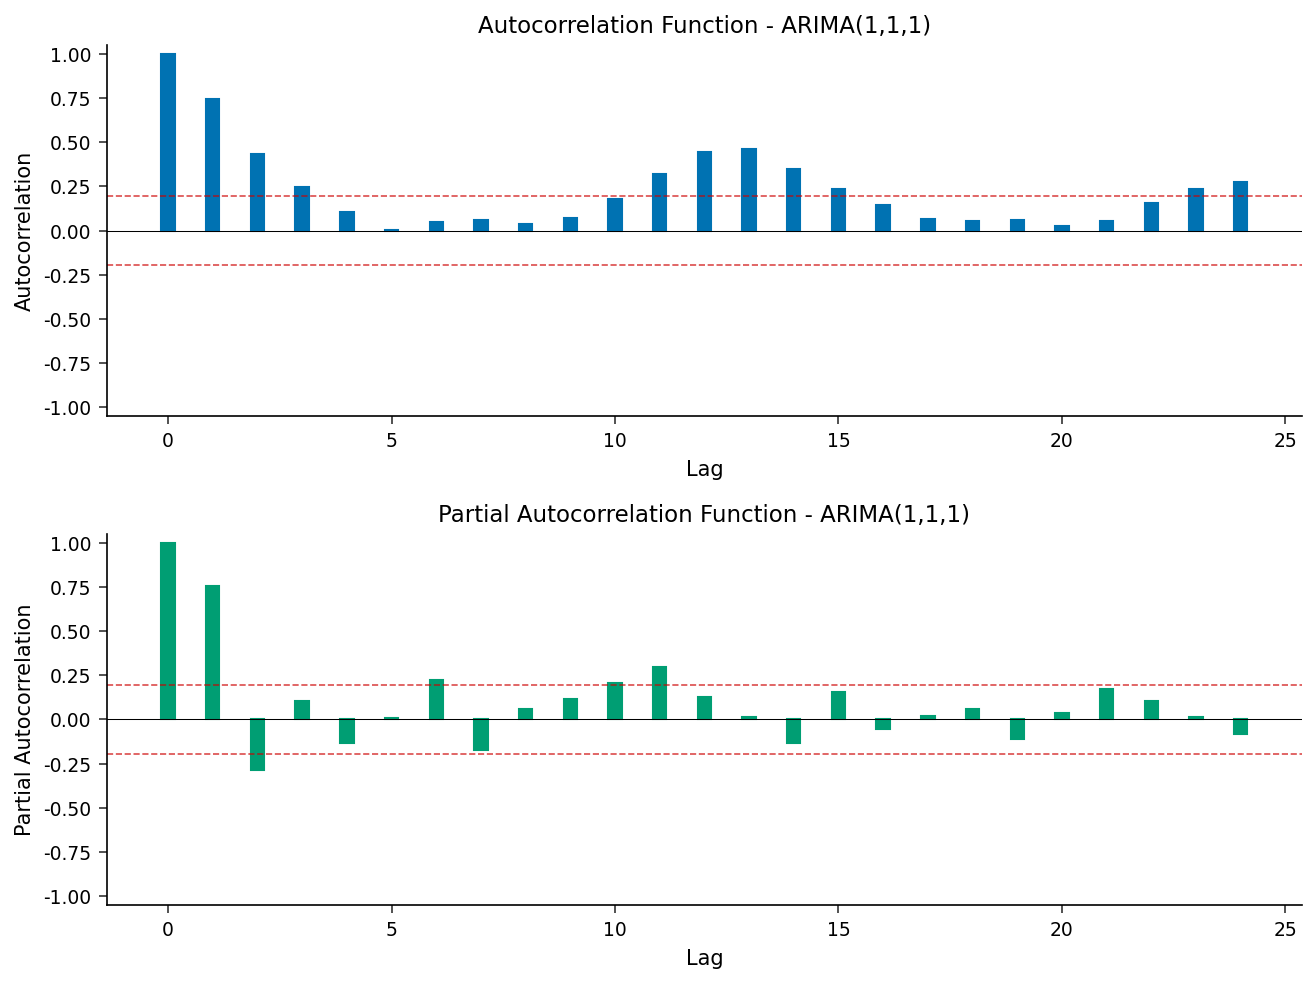

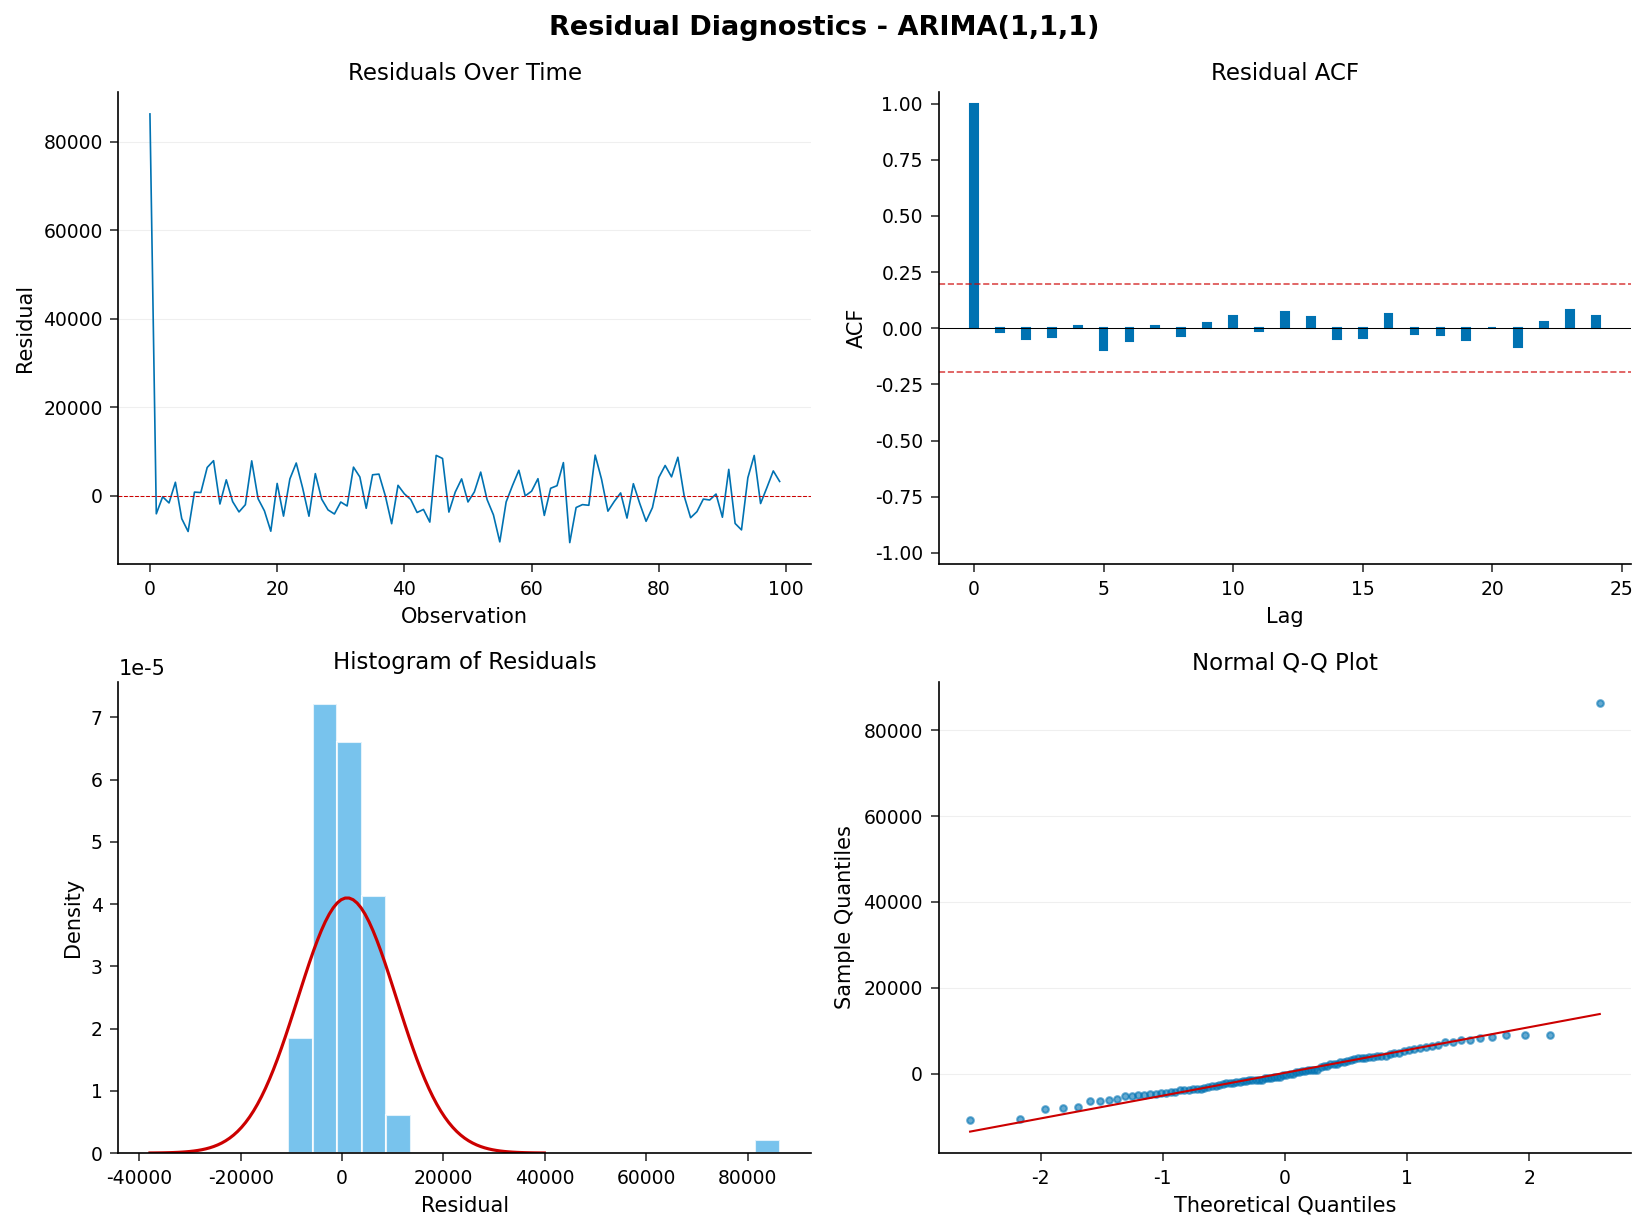

In [4]:
/* --------------------------------------------------------
   IDENTIFY + ESTIMATE en une seule étape.
   IDENTIFY différencie la série (d=1) et rapporte l'ACF
   avec NLAG=24 ; ESTIMATE ajuste un ARIMA(1,1,1) par maximum
   de vraisemblance. ODS OUTPUT capture les tableaux des
   paramètres et d'ajustement pour la documentation.
   -------------------------------------------------------- */
ODS SORTIE ParameterEstimates=work.arima_params
           FitStatistics=work.arima_fit;

PROCÉDURE ARIMA DONNÉES=work.drug_demand;
    IDENTIFY VAR=fill_volume(1) NLAG=24;
    ESTIMATION p=1 q=1 METHOD=ml;
    TITRE "ARIMA(1,1,1) - Identification et estimation : demande du médicament";
EXÉCUTER;

ODS SORTIE CLOSE;

                            Synthèse annuelle de la demande du médicament : CARDIOSTAT 40MG                             

The ARIMA Procedure





NOTE: PROC ARIMA data=work.drug_demand

NOTE: Using Python statsmodels version 0.14.6
NOTE: Output dataset work.forecasts created with 112 observations.
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_forecast.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.


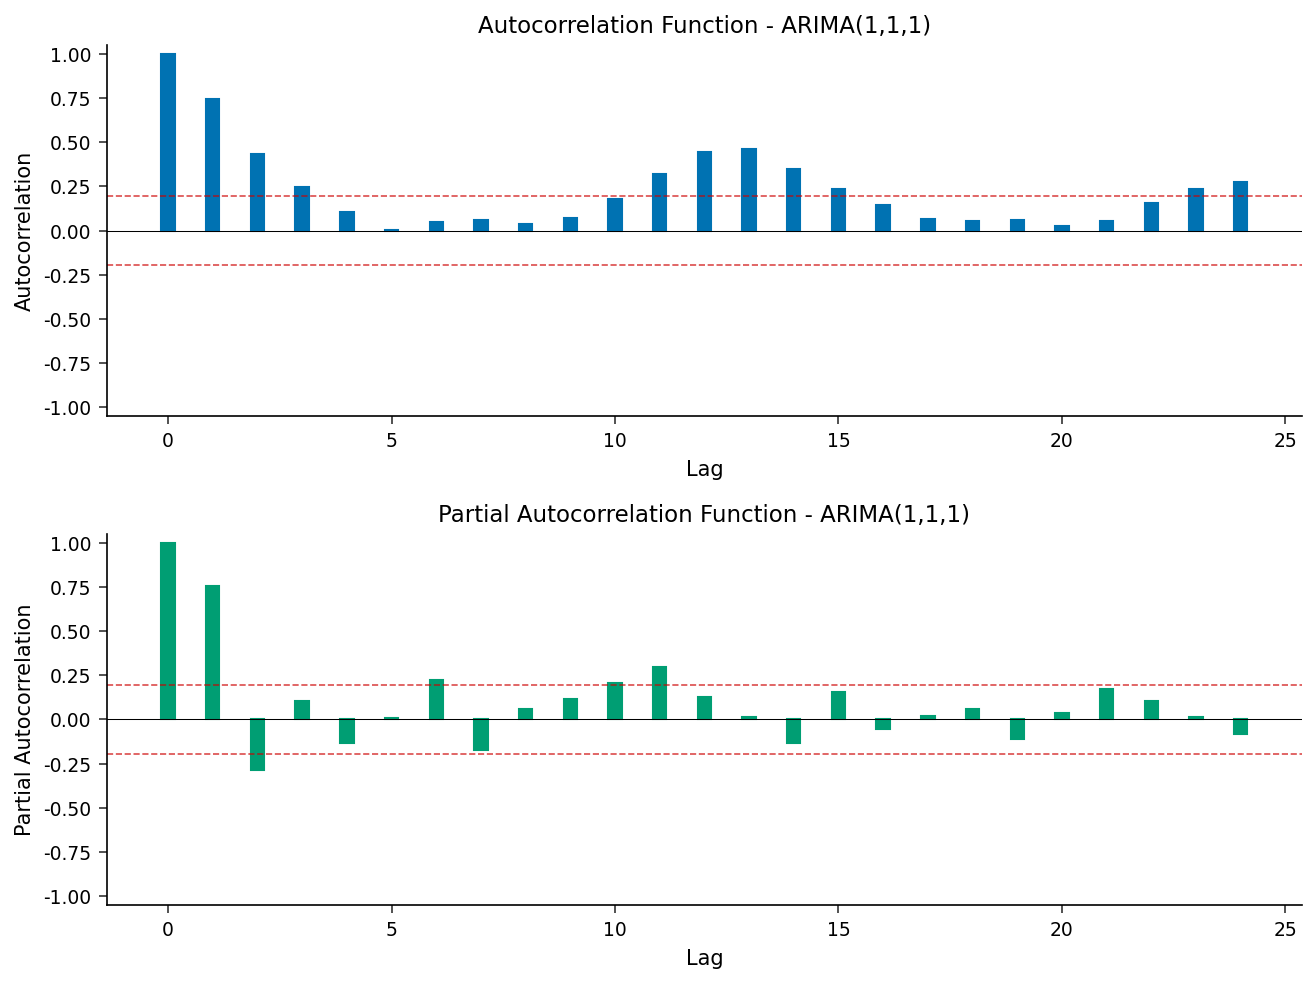

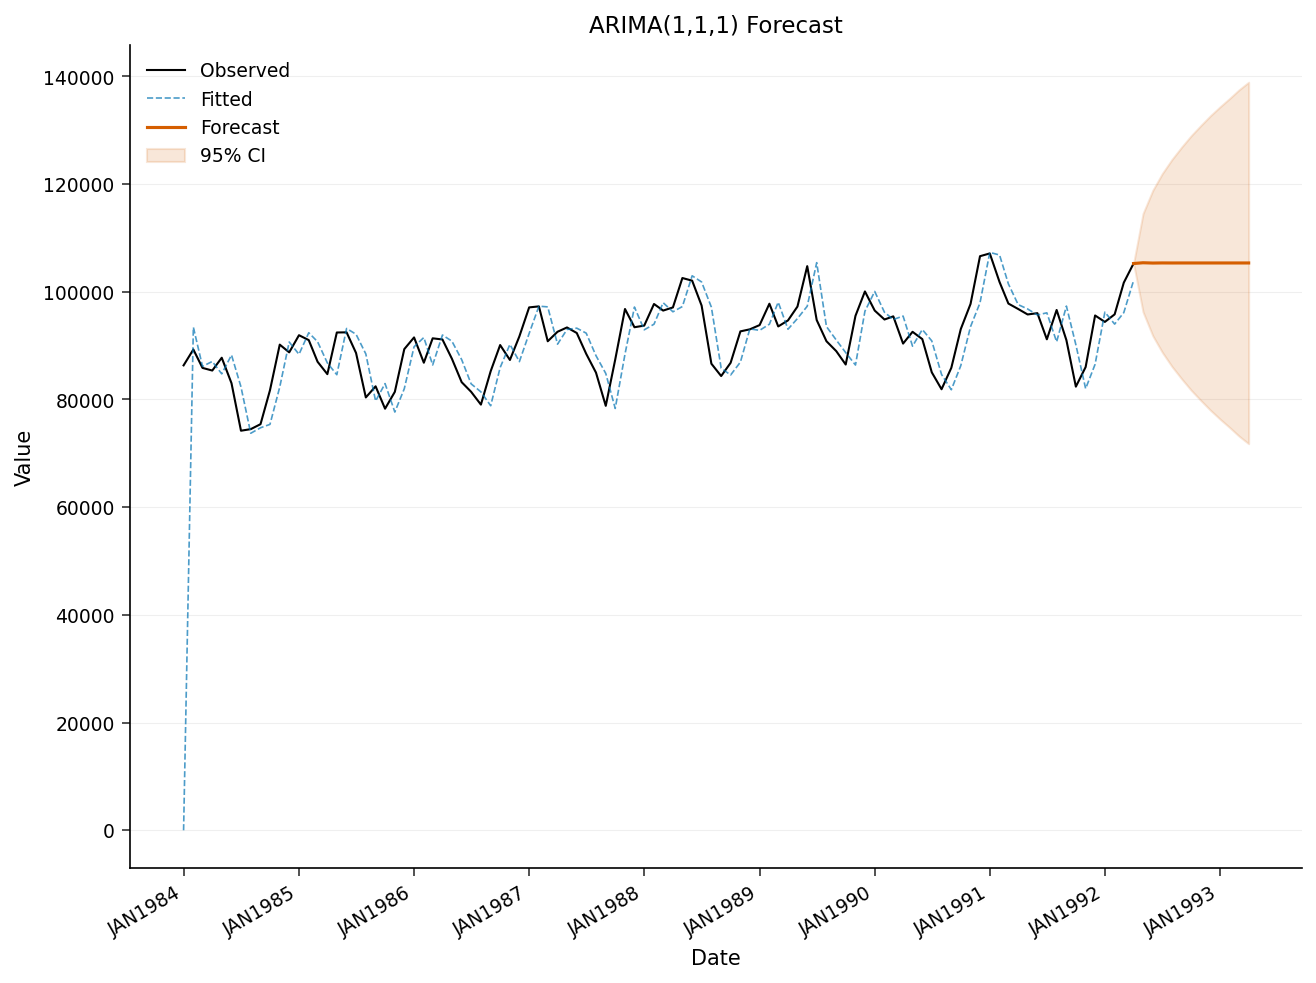

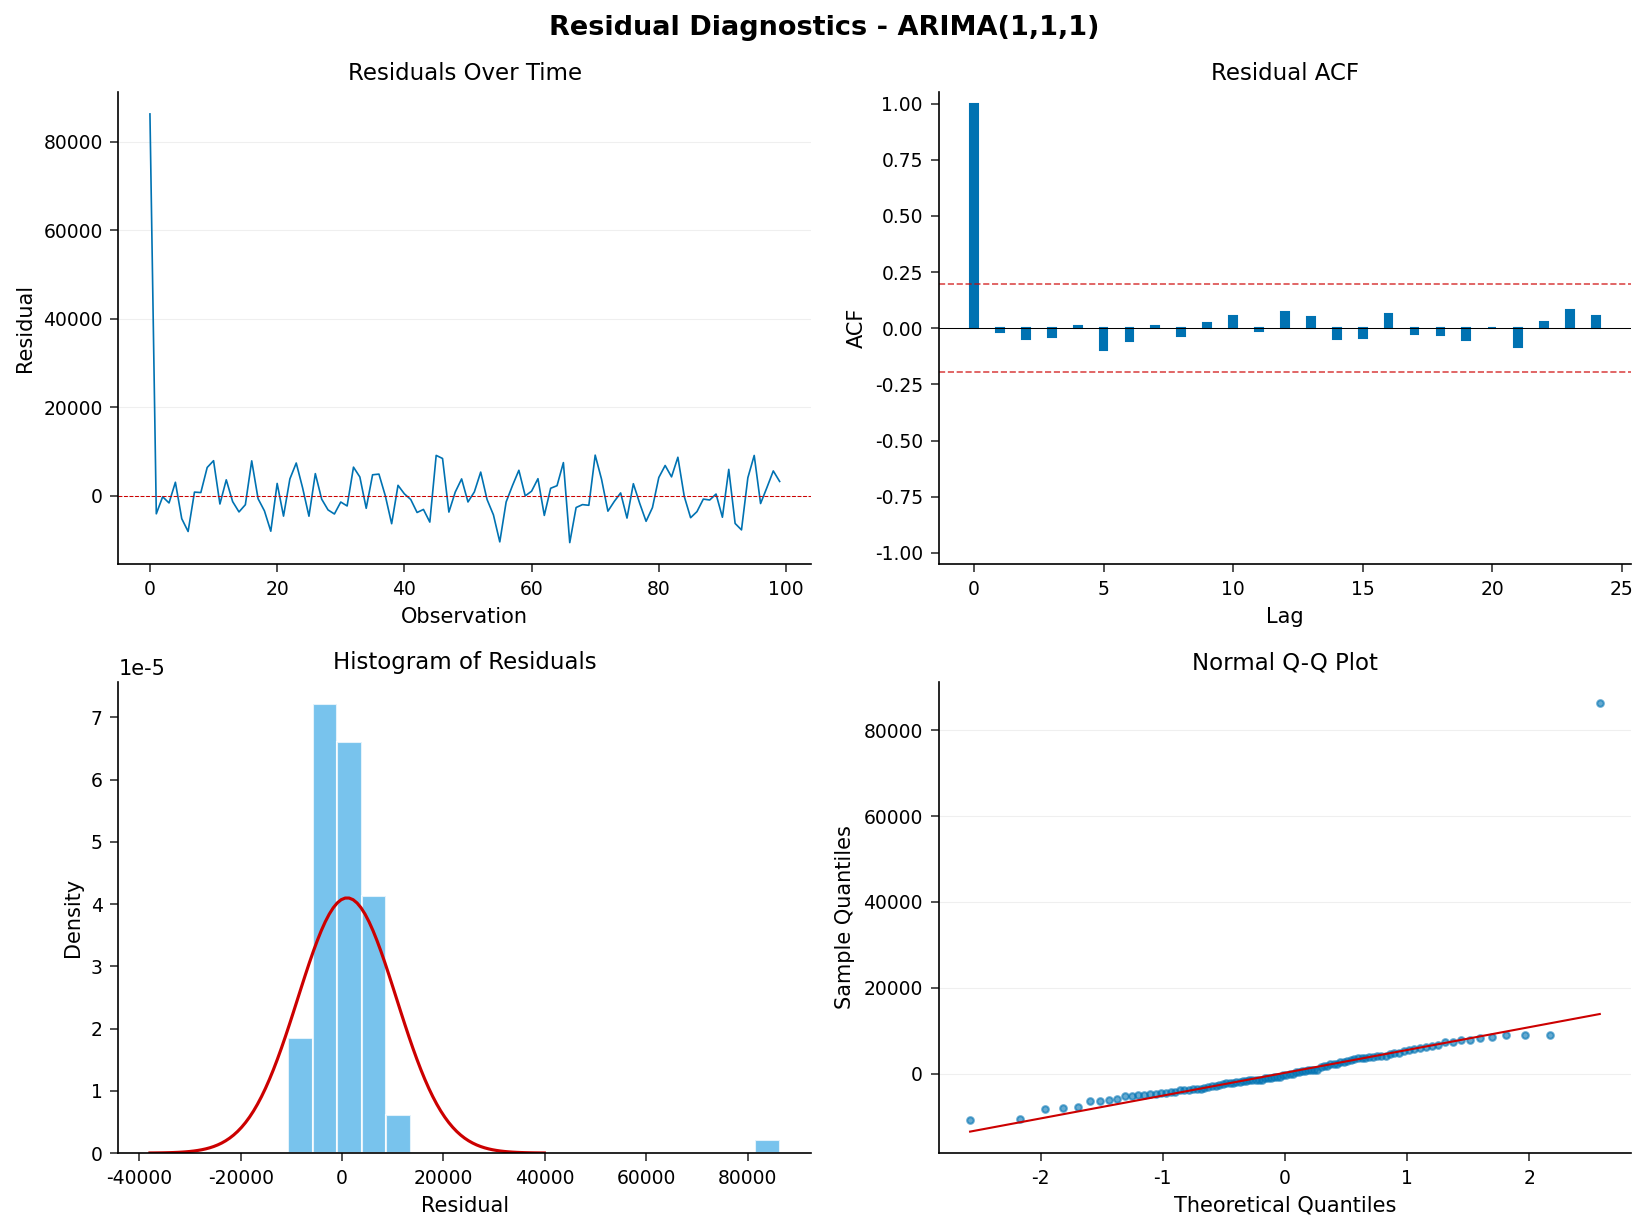

In [5]:
/* --------------------------------------------------------
   FORECAST : 12 mois d'avance pour la planification logistique
   -------------------------------------------------------- */
PROCÉDURE ARIMA DONNÉES=work.drug_demand;
    IDENTIFY VAR=fill_volume(1) NLAG=24 SANS_IMPRESSION;
    ESTIMATION p=1 q=1 METHOD=ml SANS_IMPRESSION;
    forecast LEAD=12 out=work.forecasts id=demand_date interval=month;
    TITRE "Prévision de la demande sur 12 mois : CARDIOSTAT 40MG";
EXÉCUTER;

---

### Interprétation

**Identification.** La fonction d'autocorrélation de la série différenciée au premier ordre commence à 0.74 (décalage 1) et décroît sur les décalages 2-4 (0.43, 0.25, 0.11), puis présente une bosse secondaire autour des décalages 11-14 — la signature résiduelle du cycle saisonnier annuel. Ce profil d'une ACF forte à faible ordre justifie un modèle ARMA de faible ordre sur les données différenciées, et nous ajustons un ARIMA(1,1,1).

**Estimation.** Le maximum de vraisemblance donne un coefficient AR(1) de **-0.39** (erreur type 0.29, t = -1.36, p = 0.18) et un coefficient MA(1) de **0.48** (erreur type 0.27, t = 1.75, p = 0.08). Aucun des deux termes n'atteint la significativité conventionnelle sur ces 100 observations, et les deux termes qui s'annulent presque indiquent que la série différenciée est proche d'un bruit blanc — c'est-à-dire que la série de niveau se comporte largement comme une marche aléatoire avec dérive. L'AIC du modèle est de **1957.45** et le BIC de **1965.24**, avec une estimation de la variance résiduelle d'environ 21.7 millions (écart-type résiduel proche de 4,660 exécutions).

**Diagnostics.** L'ACF des résidus ne montre aucun pic en dehors des bandes d'erreur type +/-2 au-delà du décalage 0, de sorte que le modèle ajusté ne laisse subsister aucune autocorrélation notable. L'histogramme et le graphique Q-Q sont approximativement normaux, à l'exception d'une seule valeur élevée à la première observation exploitable, qui correspond à l'effet de démarrage attendu de la différenciation.

**Prévision.** La prévision centrale à 12 mois est essentiellement plate, autour de **105,400 exécutions par mois**, ancrée sur le niveau observé le plus récent (105,251 exécutions). Reflétant la faiblesse du signal, l'intervalle de prédiction à 95% s'élargit régulièrement, d'environ +/-12,000 exécutions au mois 1 à environ **[71,800; 138,900]** au mois 12. Pour la planification de la chaîne d'approvisionnement, cela plaide pour un approvisionnement calé sur la trajectoire centrale d'environ 105,000 exécutions tout en conservant un stock de sécurité dimensionné sur l'intervalle inférieur, plutôt que de miser sur une forte poussée saisonnière que les données ne soutiennent pas.

---

In [6]:
/* --------------------------------------------------------
   Exporte le tableau des paramètres ARIMA pour la documentation
   du modèle (l'artefact référencé dans le résumé analytique).
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.arima_params
    OUTFILE='arima_parameter_estimates.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=work.arima_params outfile=arima_parameter_estimates.csv

NOTE: Exported 2 rows to arima_parameter_estimates.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>